In [55]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist

import sys
import os
from src.model import build_cnn_model
sys.path.append(os.path.abspath(".."))

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [30]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [31]:
print("=" * 50)
print("MNIST Dataset Information")
print("=" * 50)

print(f"Training Images Shape : {X_train.shape}")
print(f"Training Labels Shape : {y_train.shape}")

print(f"\nTesting Images Shape : {X_test.shape}")
print(f"Testing Labels Shape : {y_test.shape}")

print("\nImage Dimensions:")
print(f"Height : {X_train.shape[1]}")
print(f"Width  : {X_train.shape[2]}")

print("\nNumber of Classes :", len(np.unique(y_train)))

print("\nClasses:", np.unique(y_train))

MNIST Dataset Information
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)

Testing Images Shape : (10000, 28, 28)
Testing Labels Shape : (10000,)

Image Dimensions:
Height : 28
Width  : 28

Number of Classes : 10

Classes: [0 1 2 3 4 5 6 7 8 9]


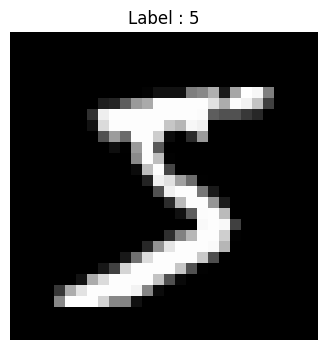

In [32]:
index = 0

plt.figure(figsize=(4,4))
plt.imshow(X_train[index], cmap="gray")
plt.title(f"Label : {y_train[index]}")
plt.axis("off")
plt.show()

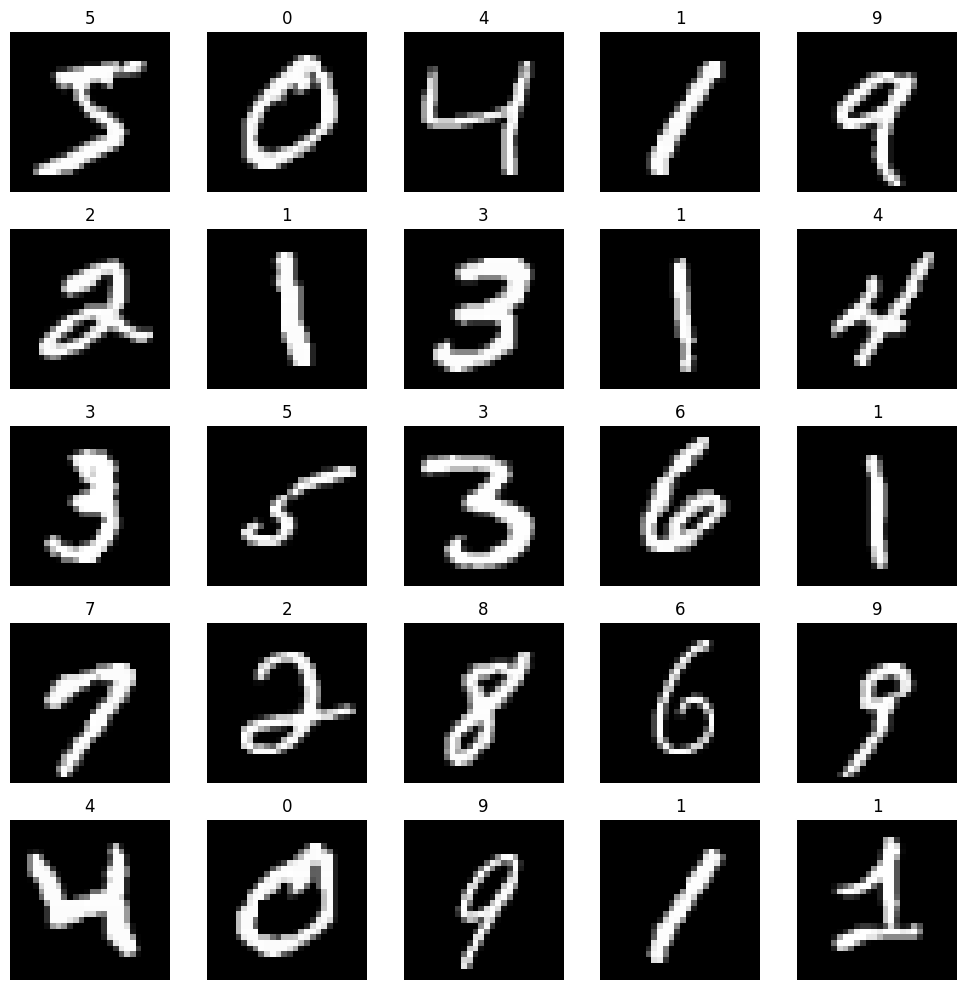

In [33]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

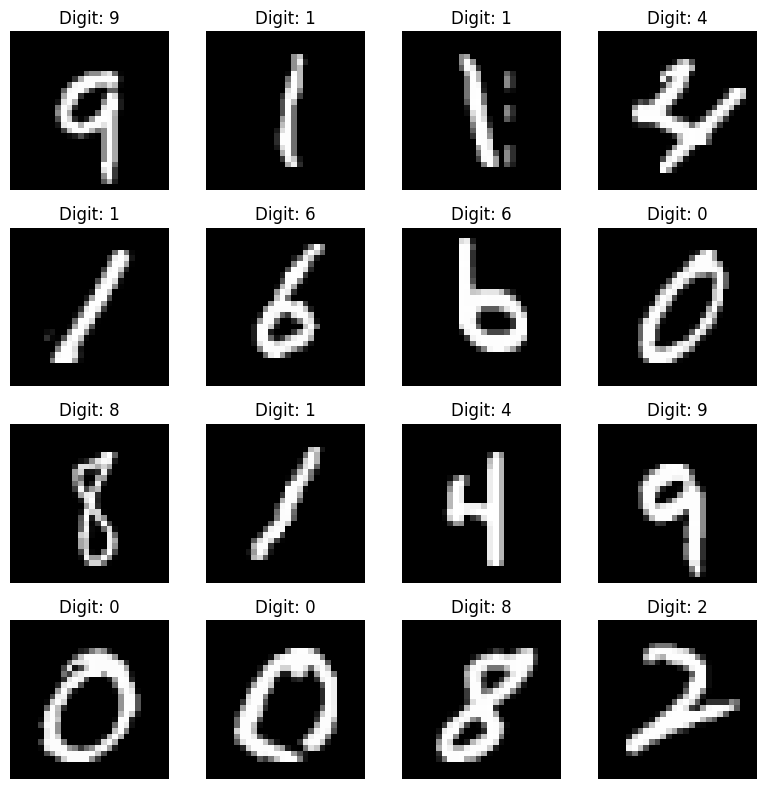

In [34]:
random_indices = np.random.randint(0, len(X_train), 16)

plt.figure(figsize=(8,8))

for i, idx in enumerate(random_indices):
    plt.subplot(4,4,i+1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(f"Digit: {y_train[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

print("\nData Type :", X_train.dtype)

Minimum Pixel Value : 0
Maximum Pixel Value : 255

Data Type : uint8


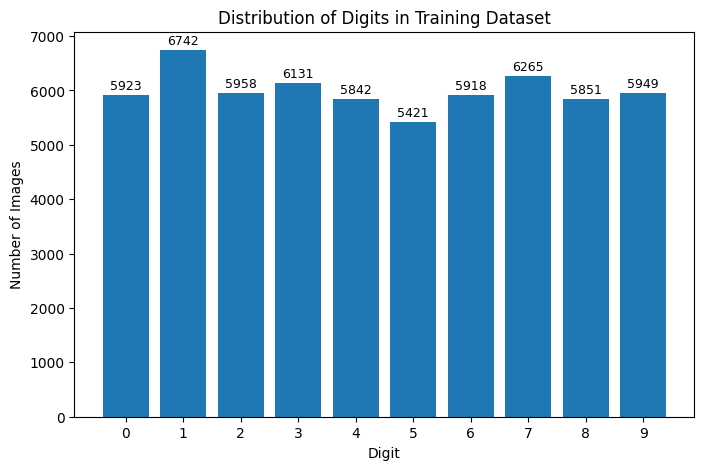

In [36]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8,5))
plt.bar(unique, counts)

plt.title("Distribution of Digits in Training Dataset")
plt.xlabel("Digit")
plt.ylabel("Number of Images")

plt.xticks(unique)

for i, count in zip(unique, counts):
    plt.text(i, count + 100, str(count), ha='center', fontsize=9)

plt.show()

In [37]:
print("=" * 60)
print("Phase 1 Summary")
print("=" * 60)

print(f"Total Training Images : {len(X_train)}")
print(f"Total Testing Images  : {len(X_test)}")
print(f"Image Size            : {X_train.shape[1]} x {X_train.shape[2]}")
print(f"Number of Classes     : {len(np.unique(y_train))}")
print(f"Pixel Range           : {X_train.min()} - {X_train.max()}")

print("\nPhase 1 completed successfully.")

Phase 1 Summary
Total Training Images : 60000
Total Testing Images  : 10000
Image Size            : 28 x 28
Number of Classes     : 10
Pixel Range           : 0 - 255

Phase 1 completed successfully.


In [38]:
from src.preprocessing import preprocess_mnist_data, display_dataset_info

In [39]:
X_train, X_test = preprocess_mnist_data(X_train, X_test)

In [40]:
display_dataset_info(X_train, X_test)

Dataset After Preprocessing
Training Shape : (60000, 28, 28, 1)
Testing Shape  : (10000, 28, 28, 1)

Training Data Type : float32
Testing Data Type  : float32

Training Min Pixel : 0.0
Training Max Pixel : 1.0

Testing Min Pixel : 0.0
Testing Max Pixel : 1.0


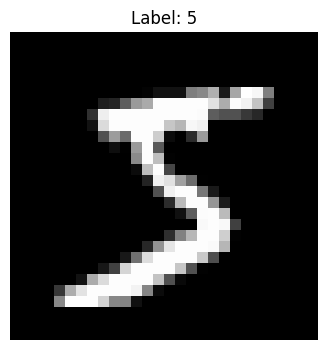

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.imshow(X_train[0].squeeze(), cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [42]:
print("Shape after preprocessing :", X_train.shape)
print("Data type                 :", X_train.dtype)
print("Pixel value range         :", X_train.min(), "to", X_train.max())

Shape after preprocessing : (60000, 28, 28, 1)
Data type                 : float32
Pixel value range         : 0.0 to 1.0


In [43]:
model = build_cnn_model()

In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

In [45]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    dpi=120
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [46]:
print("=" * 50)
print("CNN MODEL INFORMATION")
print("=" * 50)

print(f"Input Shape  : {model.input_shape}")
print(f"Output Shape : {model.output_shape}")

print(f"\nTotal Layers : {len(model.layers)}")

print("\nModel Compiled Successfully!")

CNN MODEL INFORMATION
Input Shape  : (None, 28, 28, 1)
Output Shape : (None, 10)

Total Layers : 10

Model Compiled Successfully!


In [47]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import os

In [48]:
os.makedirs("model", exist_ok=True)

In [49]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath="../model/mnist_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [50]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8961 - loss: 0.3460
Epoch 1: val_accuracy improved from None to 0.97908, saving model to ../model/mnist_cnn.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 134s 82ms/step - accuracy: 0.9455 - loss: 0.1831 - val_accuracy: 0.9791 - val_loss: 0.0711
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9760 - loss: 0.0836
Epoch 2: val_accuracy improved from 0.97908 to 0.98483, saving model to ../model/mnist_cnn.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 147s 87ms/step - accuracy: 0.9767 - loss: 0.0803 - val_accuracy: 0.9848 - val_loss: 0.0587
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9834 - loss: 0.0573
Epoch 3: val_accuracy improved from 0.98483 to 0.98708, saving model to ../model/mnist_cnn.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 130s 78ms/step - accuracy: 0.9831 - loss: 0.0578 - val_accuracy: 0.9871 - val_loss: 0.0475
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9851 - los

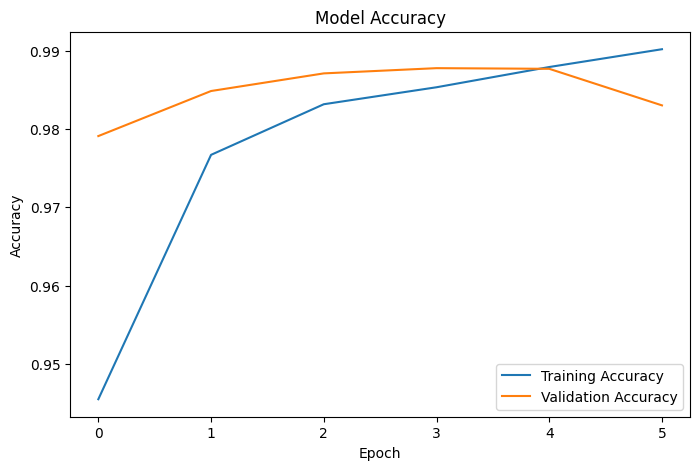

In [51]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

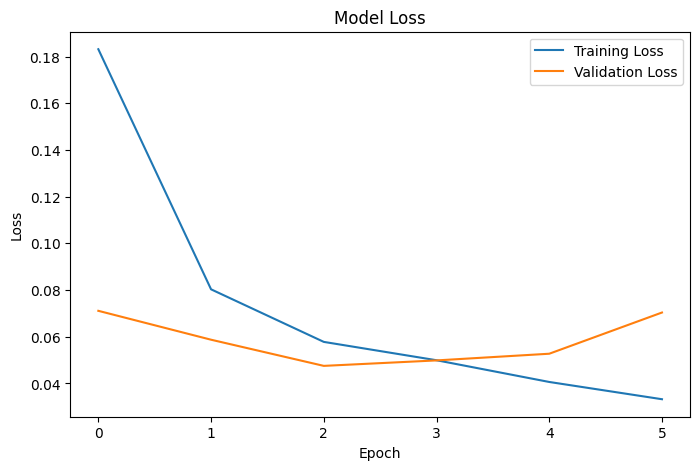

In [52]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [53]:
print("=" * 50)
print("Training Completed")
print("=" * 50)

print(f"Final Training Accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}")

print(f"\nFinal Training Loss       : {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {history.history['val_loss'][-1]:.4f}")

Training Completed
Final Training Accuracy   : 0.9902
Final Validation Accuracy : 0.9830

Final Training Loss       : 0.0332
Final Validation Loss     : 0.0704


In [54]:
model.save("../model/final_mnist_cnn.keras")

In [56]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

MODEL EVALUATION
Test Loss     : 0.0366
Test Accuracy : 0.9880


In [57]:
predictions = model.predict(X_test, verbose=0)

predicted_labels = np.argmax(predictions, axis=1)

In [58]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(y_test, predicted_labels))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.98      1.00      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      1.00      0.99       892
           6       1.00      0.97      0.99       958
           7       0.98      0.99      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



<Figure size 800x800 with 0 Axes>

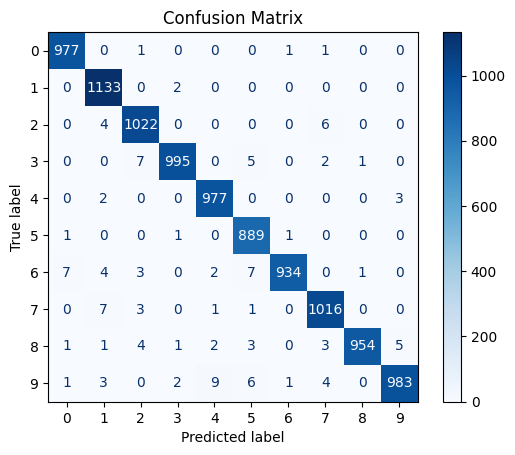

In [59]:
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix")
plt.show()

In [60]:
incorrect = np.where(predicted_labels != y_test)[0]

print(f"Total Incorrect Predictions: {len(incorrect)}")

Total Incorrect Predictions: 120


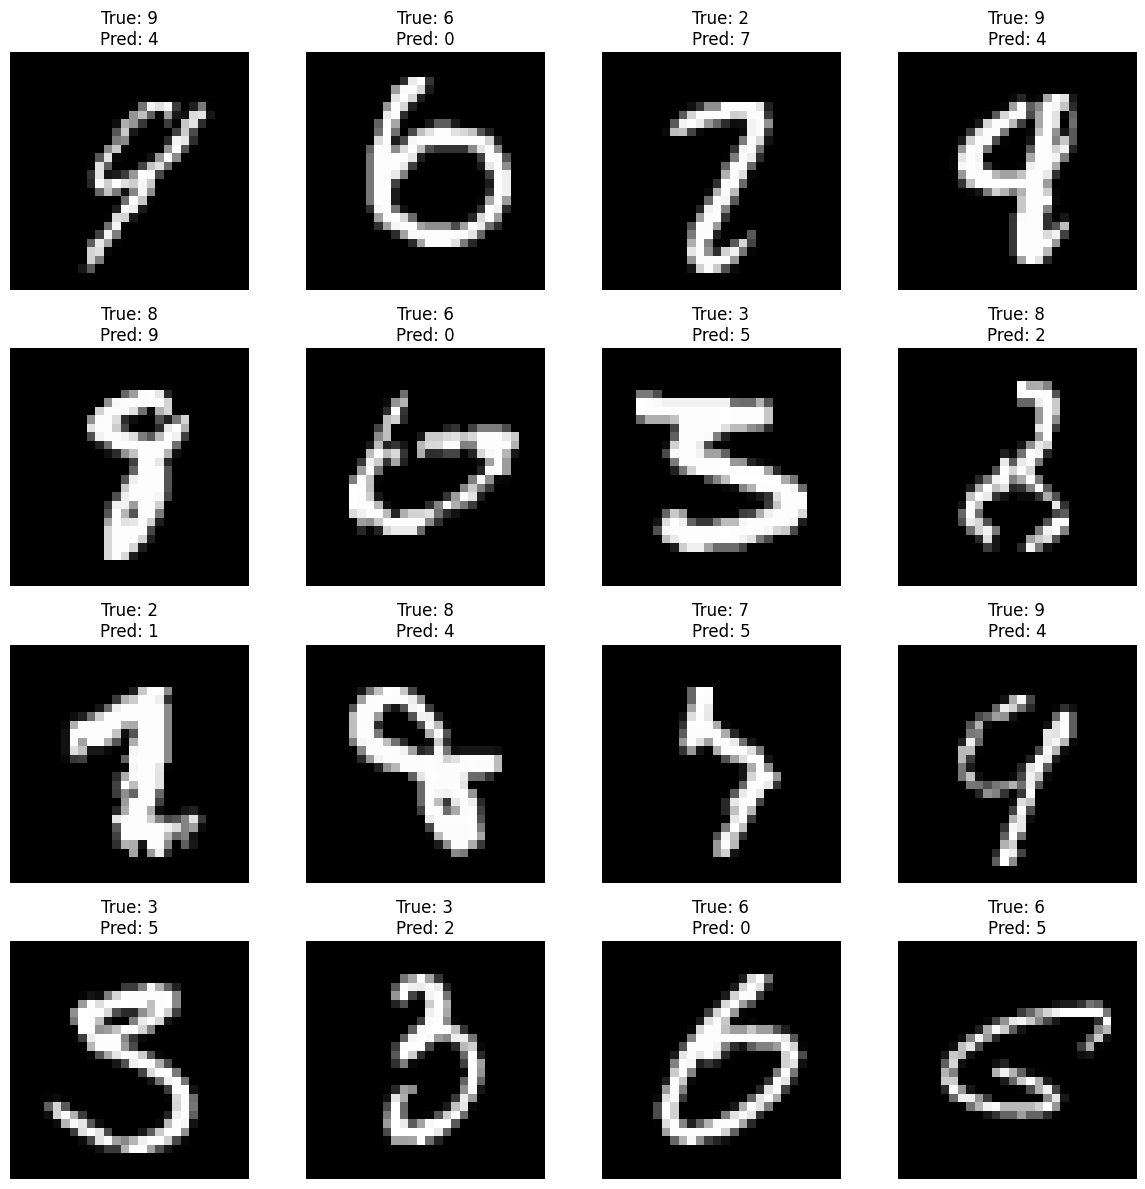

In [61]:
plt.figure(figsize=(12,12))

for i, idx in enumerate(incorrect[:16]):
    plt.subplot(4,4,i+1)

    plt.imshow(X_test[idx].squeeze(), cmap="gray")

    plt.title(
        f"True: {y_test[idx]}\nPred: {predicted_labels[idx]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

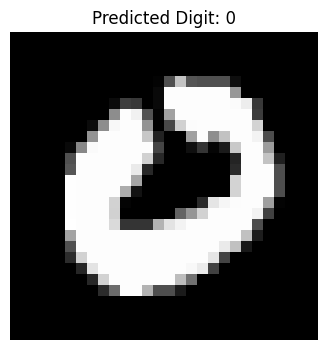

Prediction : 0
Confidence : 100.00%


In [62]:
index = 25

image = X_test[index]

prediction = model.predict(
    image.reshape(1,28,28,1),
    verbose=0
)

digit = np.argmax(prediction)

confidence = prediction[0][digit]

plt.figure(figsize=(4,4))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Predicted Digit: {digit}")
plt.axis("off")
plt.show()

print(f"Prediction : {digit}")
print(f"Confidence : {confidence*100:.2f}%")

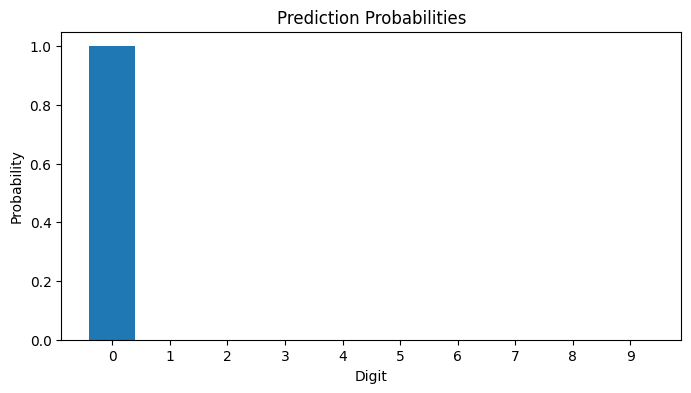

In [63]:
plt.figure(figsize=(8,4))

plt.bar(
    np.arange(10),
    prediction[0]
)

plt.xticks(np.arange(10))
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.title("Prediction Probabilities")

plt.show()

In [64]:
evaluation = {
    "Test Accuracy": round(float(test_accuracy), 4),
    "Test Loss": round(float(test_loss), 4),
    "Incorrect Predictions": len(incorrect)
}

print(evaluation)

{'Test Accuracy': 0.988, 'Test Loss': 0.0366, 'Incorrect Predictions': 120}


In [65]:
from src.predict import (
    load_trained_model,
    preprocess_uploaded_image,
    predict_digit
)

In [66]:
loaded_model = load_trained_model("../model/mnist_cnn.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


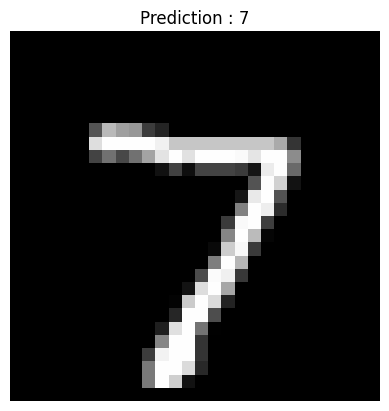

Confidence : 100.00%


In [67]:
sample = X_test[0]

prediction = loaded_model.predict(
    sample.reshape(1,28,28,1),
    verbose=0
)

digit = np.argmax(prediction)

confidence = prediction[0][digit]

plt.imshow(sample.squeeze(), cmap="gray")
plt.title(f"Prediction : {digit}")
plt.axis("off")

plt.show()

print(f"Confidence : {confidence*100:.2f}%")

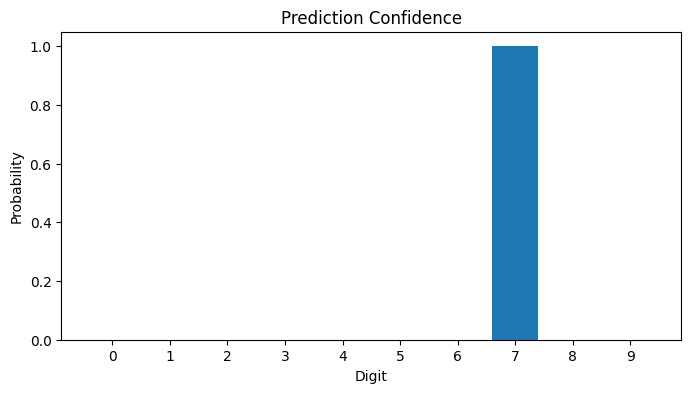

In [68]:
plt.figure(figsize=(8,4))

plt.bar(
    range(10),
    prediction[0]
)

plt.xlabel("Digit")
plt.ylabel("Probability")
plt.title("Prediction Confidence")

plt.xticks(range(10))

plt.show()

Predicted Digit : 1
Confidence       : 100.00%


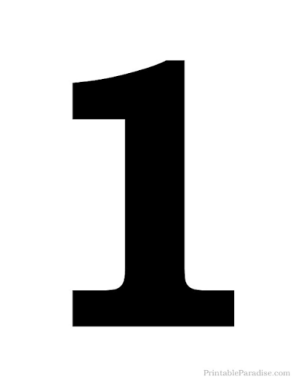

In [69]:
from PIL import Image

image = Image.open("../assets/images/digit.png")

processed_image = preprocess_uploaded_image(image)

digit, confidence, probabilities = predict_digit(
    loaded_model,
    processed_image
)

print(f"Predicted Digit : {digit}")
print(f"Confidence       : {confidence*100:.2f}%")

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()